# torch-cnmf Inference Tutorial

This notebook demonstrates how to run torch-cnmf on the PBMC3k dataset from scanpy.

Steps:
1. Load Data
2. Set Parameters
3. Prepare (initialize cNMF, normalize, select high-variance genes)
4. Factorize (run NMF)
5. Combine replicates
6. K Selection
7. Consensus
8. Load and Visualize Results
9. UMAP Visualization
10. Save Results to MuData
11. Gene Annotation

## Expected Output Structure

After running the full inference pipeline, the output directory will have the following structure:

```
<output_directory>/<run_name>/
└── Inference/
    ├── cnmf_tmp/                                          # Internal cNMF working files
    │   ├── Inference.norm_counts.h5ad                     # Normalized + HVG-filtered counts
    │   ├── Inference.overdispersed_genes.txt               # List of selected high-variance genes
    │   ├── Inference.nmf_idvrun_spectra.k_<K>.iter_<i>.df.npz   # Per-replicate H matrix (one per K x iter)
    │   ├── Inference.nmf_idvrun_usage.k_<K>.iter_<i>.df.npz     # Per-replicate W matrix (one per K x iter)
    │   ├── Inference.spectra.k_<K>.merged.df.npz          # Merged H matrices across replicates
    │   ├── Inference.usages.k_<K>.merged.df.npz           # Merged W matrices across replicates
    │   ├── Inference.spectra.k_<K>.dt_<thresh>.consensus.df.npz  # Consensus H after density filtering
    │   ├── Inference.usages.k_<K>.dt_<thresh>.consensus.df.npz   # Consensus W after density filtering
    │   ├── Inference.gene_spectra_score.k_<K>.dt_<thresh>.txt    # Z-scored gene spectra (genes x programs)
    │   ├── Inference.gene_spectra_tpm.k_<K>.dt_<thresh>.txt      # TPM-scaled gene spectra
    │   ├── Inference.k_selection_stats.df.npz              # Stability and error stats for K selection
    │   └── Inference.clustering.k_<K>.dt_<thresh>.npz      # Clustering assignments
    │
    ├── adata/                                             # Compiled MuData objects
    │   └── cNMF_<K>_<thresh>.h5mu                         # MuData with "rna" + "cNMF" modalities
    │                                                      #   rna: original counts, obs, var
    │                                                      #   cNMF: usage matrix (cells x programs),
    │                                                      #          loadings in varm, spectra scores in var
    │
    ├── loading/                                           # Gene loading matrices
    │   └── cNMF_<K>_<thresh>_loading.npz                  # Sparse gene x program loading matrix
    │
    ├── prog_data/                                         # Program-level summary data
    │   └── cNMF_<K>_<thresh>_prog_data.csv                # Per-program metadata (top genes, stats)
    │
    ├── Annotation/                                        # Gene annotation Excel files
    │   └── <K>_<thresh>.xlsx                              # Top genes per program with enrichment annotations
    │
    ├── Inference.gene_spectra_score.k_<K>.dt_<thresh>.txt # Gene spectra scores (symlinked or copied)
    ├── Inference.spectra.k_<K>.dt_<thresh>.consensus.txt  # Consensus spectra as TSV
    └── config_<SLURM_JOB_ID>.yml                          # Run configuration snapshot
```

**Key files for downstream analysis:**

| File | Description | Used by |
|------|-------------|---------|
| `adata/cNMF_<K>_<thresh>.h5mu` | Primary output — MuData with programs + expression | Evaluation, Plotting, Calibration |
| `cnmf_tmp/Inference.norm_counts.h5ad` | Normalized counts (HVG-filtered) | Evaluation (explained variance) |
| `cnmf_tmp/Inference.k_selection_stats.df.npz` | Stability/error per K | K-selection plotting |
| `Annotation/<K>_<thresh>.xlsx` | Gene annotations per program | Manual inspection |
| `Inference.gene_spectra_score.k_<K>.dt_<thresh>.txt` | Z-scored gene loadings | Gene-level analysis |

**Notes:**
- `<K>` = number of components (e.g., 5, 7, 10)
- `<thresh>` = density threshold with `.` replaced by `_` (e.g., `2_0` for threshold 2.0)
- Files in `cnmf_tmp/` use the prefix `Inference.` (the cNMF internal run name)
- When running parallel K values via SLURM array jobs, each K produces its own `<run_name>_<K>/Inference/` directory; these are later consolidated

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import anndata
import muon
import os
import sys
import torch

sys.path.append('/oak/stanford/groups/engreitz/Users/ymo/Tools/PerturbNMF/src')

from torch_cnmf import cNMF
from Stage1_Inference.src import compile_results, get_top_indices_fast, annotate_genes_to_excel

In [2]:
# Check GPU availability
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Version: {torch.version.cuda}")
print(f"Number of GPUs: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Current GPU: {torch.cuda.get_device_name(0)}")

CUDA Available: True
CUDA Version: 12.4
Number of GPUs: 1
Current GPU: NVIDIA GeForce RTX 2080 Ti


## Step 1. Load Data

In [3]:
adata = sc.datasets.pbmc3k()
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

In [4]:
# Save counts to h5ad for cNMF input
counts_fn = "example_output/pbmc3k.h5ad"
os.makedirs("example_output", exist_ok=True)
adata.write(counts_fn)

## Step 2. Set Parameters

In [5]:
# NMF parameters
n_iter = 10                           # number of NMF replicates per K
num_highvar_genes = 2000              # number of overdispersed genes to select
K = [5, 7, 10]                        # list of component counts (K) to factorize
seed = 14                             # random seed for reproducibility
beta_loss = "frobenius"               # loss function: "frobenius" or "kullback-leibler"
init = "random"                       # initialization method: "random" or "nndsvd"
algo = "halsvar"                      # NMF algorithm: "halsvar", "mu", or "cd"
mode = "minibatch"                    # execution mode: "batch", "minibatch", or "dataloader"
tol = 1e-4                            # convergence tolerance for NMF
use_gpu = True                        # whether to use GPU acceleration

# Batch mode parameters
batch_max_epoch = 500                 # max epochs for batch mode
batch_hals_tol = 0.005                # HALS convergence tolerance in batch mode
batch_hals_max_iter = 1000            # max HALS inner iterations in batch mode

# Minibatch/dataloader mode parameters
minibatch_max_epoch = 500             # max epochs for minibatch mode
minibatch_size = 500                  # number of cells per minibatch
minibatch_max_iter = 1000             # max iterations per minibatch epoch
minibatch_usage_tol = 0.005           # convergence tolerance for usage (W) updates
minibatch_spectra_tol = 0.005         # convergence tolerance for spectra (H) updates
minibatch_shuffle = False             # whether to shuffle cells between epochs

# Refit parameters
sk_cd_refit = False                   # refit W with sklearn coordinate descent after NMF

# Consensus parameters
density_thresholds = [2.0]            # density filtering thresholds for consensus clustering

# Paths
output_directory = "example_output/cNMF"  # base output directory
run_name = "pbmc_test"                    # name for this cNMF run

# ── Compile results parameters ──
# These are used by compile_results() and the gene annotation step
components = K                        # K values to compile
sel_threshs = density_thresholds      # density thresholds to compile
categorical_key = None                # obs column with sample/condition labels (None if not available)
guide_names_key = None                # uns key for guide names (None if no perturbation data)
guide_targets_key = None              # uns key for guide targets (None if no perturbation data)
guide_assignment_key = None           # obsm key for guide assignments (None if no perturbation data)
gene_names_key = 'gene_ids'                 # var column to use as gene names (None = use var_names)

# ── Gene annotation parameters ──
gene_num = 300                        # number of top genes per program to annotate
species = "human"                     # "human" or "mouse"

## Step 3. Prepare

In [ ]:
run_dir = f'{output_directory}/{run_name}'
inference_dir = f'{run_dir}/Inference'
os.makedirs(inference_dir, exist_ok=True)

cnmf_obj = cNMF(output_dir=run_dir, name='Inference')

In [7]:
cnmf_obj.prepare(
    counts_fn=counts_fn,
    components=K,
    n_iter=n_iter,
    num_highvar_genes=num_highvar_genes,
    seed=seed,
    beta_loss=beta_loss,
    init=init,
    algo=algo,
    mode=mode,
    tol=tol,
    use_gpu=use_gpu,
    alpha_usage=0.0,
    alpha_spectra=0.0,
    l1_ratio_usage=0.0,
    l1_ratio_spectra=0.0,
    fp_precision="float",
    batch_max_epoch=batch_max_epoch,
    batch_hals_tol=batch_hals_tol,
    batch_hals_max_iter=batch_hals_max_iter,
    minibatch_max_epoch=minibatch_max_epoch,
    minibatch_size=minibatch_size,
    minibatch_max_iter=minibatch_max_iter,
    minibatch_usage_tol=minibatch_usage_tol,
    minibatch_spectra_tol=minibatch_spectra_tol,
    minibatch_shuffle=minibatch_shuffle,
    sk_cd_refit=sk_cd_refit,
)

Number of genes with zero variance: 16104
Genes with zero variance removed: ['MIR1302-10', 'FAM138A', 'OR4F5', 'RP11-34P13.7', 'RP11-34P13.8', 'RP11-34P13.14', 'RP11-34P13.9', 'RP4-669L17.10', 'OR4F29', 'RP4-669L17.2', 'RP5-857K21.15', 'RP5-857K21.1', 'RP5-857K21.2', 'RP5-857K21.3', 'RP5-857K21.4', 'RP5-857K21.5', 'OR4F16', 'RP11-206L10.3', 'RP11-206L10.5', 'RP11-206L10.4', 'AL669831.1', 'AL645608.2', 'RP11-54O7.16', 'RP11-54O7.1', 'RP11-54O7.2', 'RP11-54O7.3', 'AL645608.1', 'C1orf170', 'RP11-54O7.18', 'RNF223', 'RP11-465B22.5', 'RP11-465B22.8', 'TTLL10-AS1', 'TTLL10', 'SCNN1D', 'RP4-758J18.13', 'RP4-758J18.7', 'TMEM88B', 'RP4-758J18.10', 'VWA1', 'TMEM240', 'RP11-345P4.7', 'CALML6', 'C1orf222', 'RP11-547D24.1', 'GABRD', 'RP11-547D24.3', 'RP11-181G12.5', 'RP11-181G12.4', 'AL589739.1', 'RP3-395M20.2', 'RP3-395M20.3', 'HES5', 'RP3-395M20.7', 'RP13-436F16.1', 'RP11-740P5.2', 'RP11-740P5.3', 'ACTRT2', 'LINC00982', 'RP1-163G9.2', 'RP11-22L13.1', 'ARHGEF16', 'RP11-168F9.2', 'RP11-46F15.2', 'R

/oak/stanford/groups/engreitz/Users/ymo/Tools/torch-cnmf/src/torch_cnmf/cnmf.py:1203: UserWarning: 30 runs already appear completed. If this is unexpected, consider
            re-initializing the cnmf object with a different run name or output directory
  warnings.warn(message, UserWarning)


## Step 4. Factorize

In [8]:
cnmf_obj.factorize(skip_completed_runs=False)

Starting task 0.
Use GPU mode.
Pass 10, loss=2248.68690764049.
Pass 20, loss=2248.690584262317.
    Converged after 20 pass(es).
Update H
Final loss=2247.9641249431115.
Starting task 1.
Use GPU mode.
Pass 10, loss=2248.687963812176.
Pass 20, loss=2248.6904244470825.
    Converged after 20 pass(es).
Update H
Final loss=2247.963932060243.
Starting task 2.
Use GPU mode.
Pass 10, loss=2248.688048062692.
Pass 20, loss=2248.690499143335.
    Converged after 20 pass(es).
Update H
Final loss=2247.9640146002116.
Starting task 3.
Use GPU mode.
Pass 10, loss=2248.6690264743274.
Pass 20, loss=2248.690704123735.
    Converged after 20 pass(es).
Update H
Final loss=2247.964238761373.
Starting task 4.
Use GPU mode.
Pass 10, loss=2248.6734969963404.
Pass 20, loss=2248.6904227099603.
    Converged after 20 pass(es).
Update H
Final loss=2247.9639355356103.
Starting task 5.
Use GPU mode.
Pass 10, loss=2251.353539921873.
Pass 20, loss=2251.3230016620228.
    Converged after 20 pass(es).
Update H
Final los

## Step 5. Combine

In [9]:
cnmf_obj.combine()

Combining factorizations for k=5.
Combining factorizations for k=7.
Combining factorizations for k=10.


## Step 6. K Selection

Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed
Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed
Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed


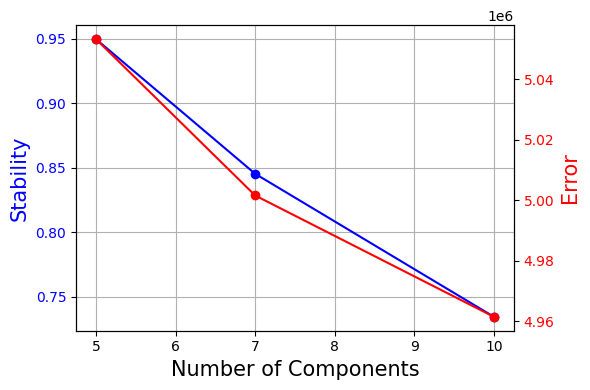

In [10]:
cnmf_obj.k_selection_plot() #minibatch un shuffle

Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed
Dropping 1/70 all-zero spectra rows.
Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed
Dropping 1/100 all-zero spectra rows.
Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed


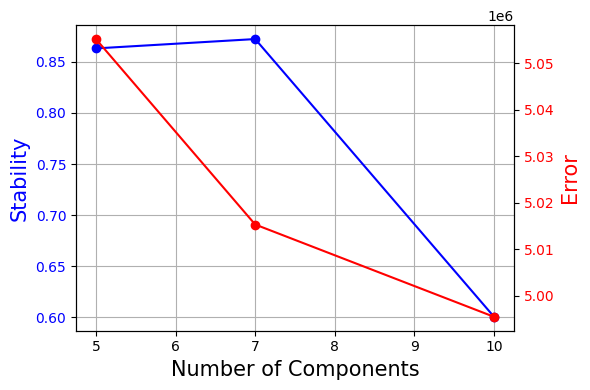

In [19]:
cnmf_obj.k_selection_plot() #minibatch shuffle

Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed
Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed
Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed


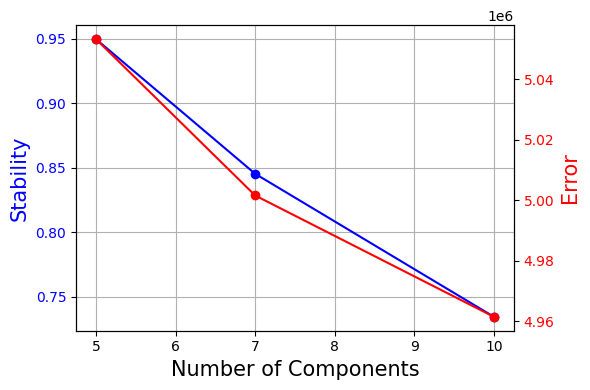

In [43]:
cnmf_obj.k_selection_plot() #dl un shuffle

Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed
Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed
Dropping 2/100 all-zero spectra rows.
Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed


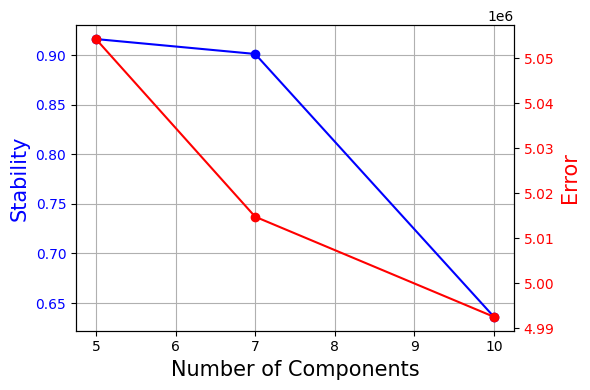

In [25]:
cnmf_obj.k_selection_plot() #dl shuffle

Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed
Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed
Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed


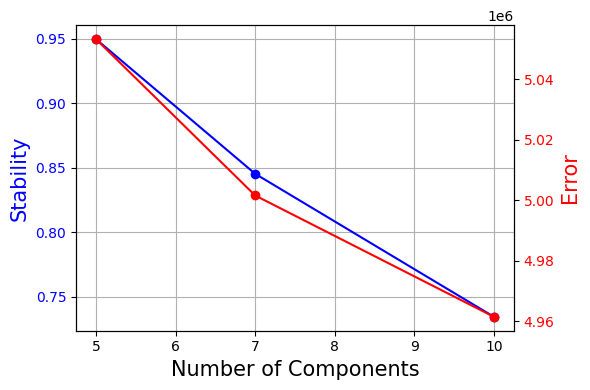

In [41]:
cnmf_obj.k_selection_plot() #batch

## Step 7. Consensus

Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed
Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed


/home/users/ymo/.local/lib/python3.9/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed
Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed
Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed


/home/users/ymo/.local/lib/python3.9/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed
Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed
Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed


/home/users/ymo/.local/lib/python3.9/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Use GPU mode.
Using torch nmf HALS with DataLoader to refit
HALS DataLoader refit completed


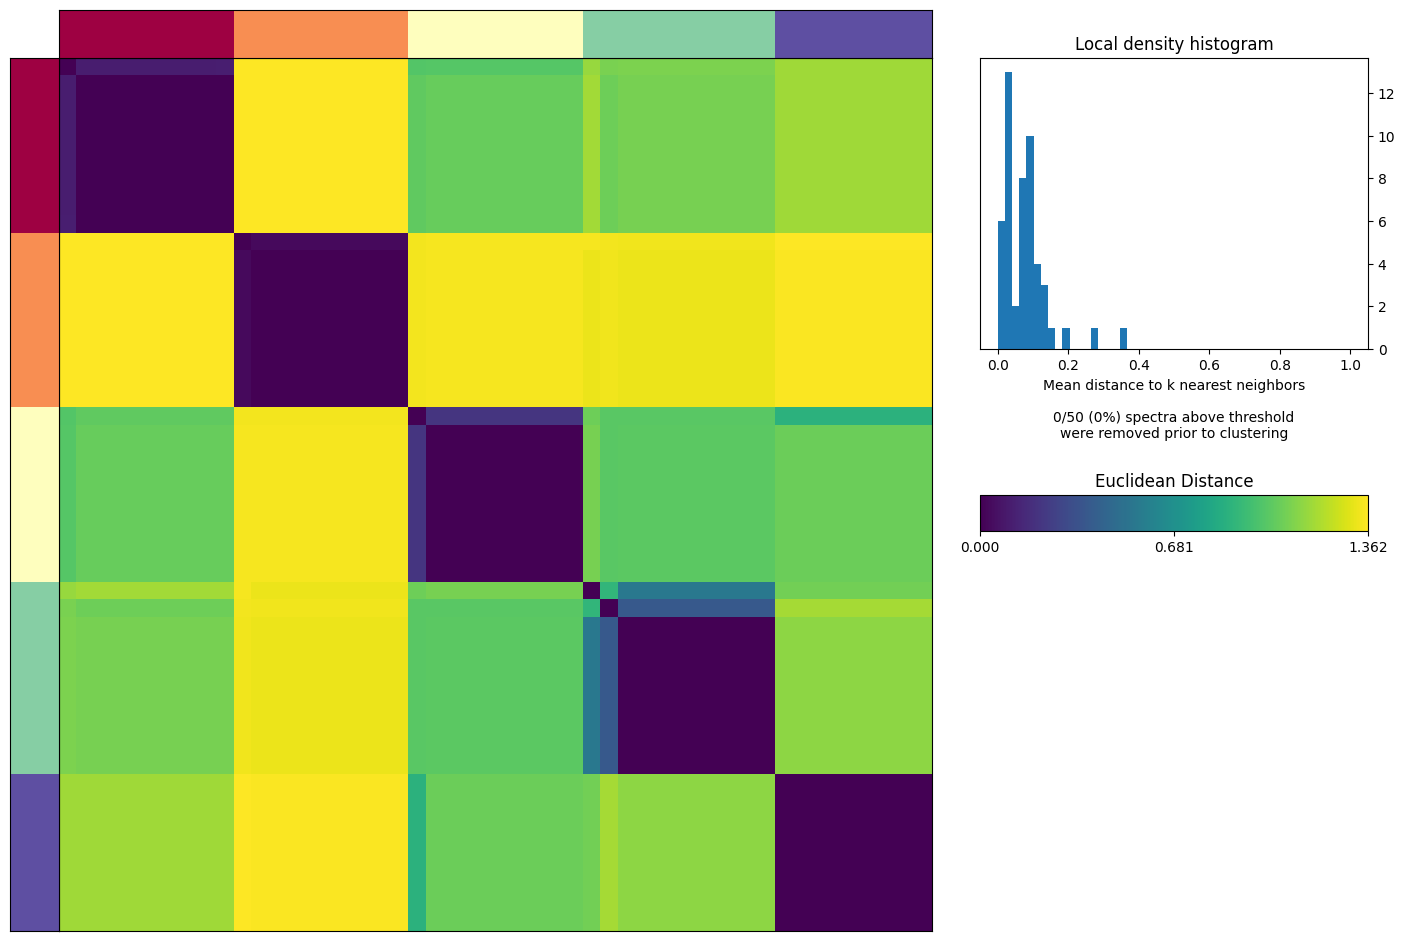

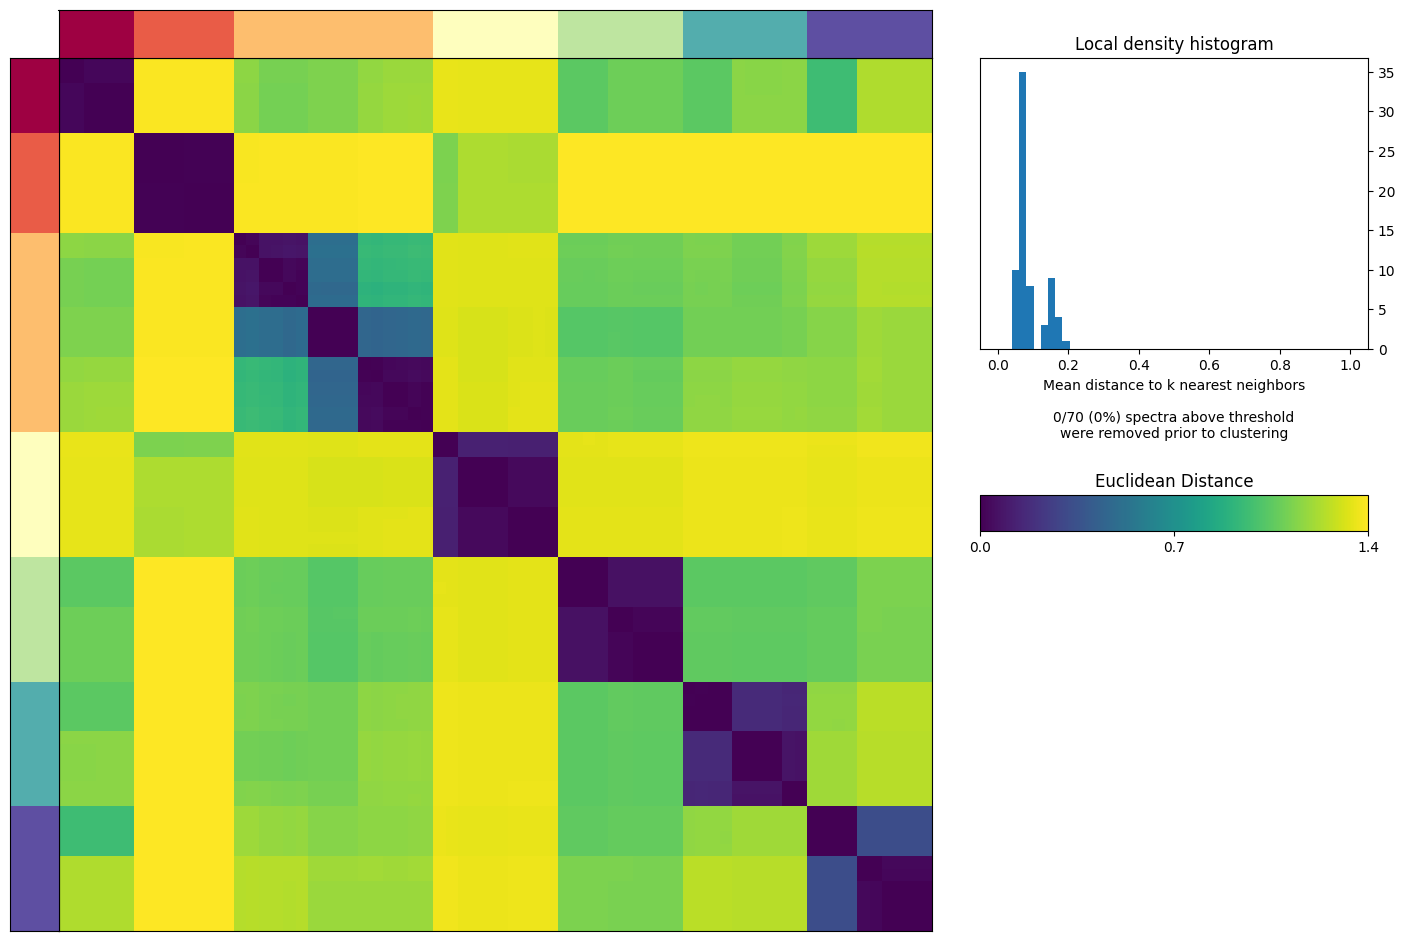

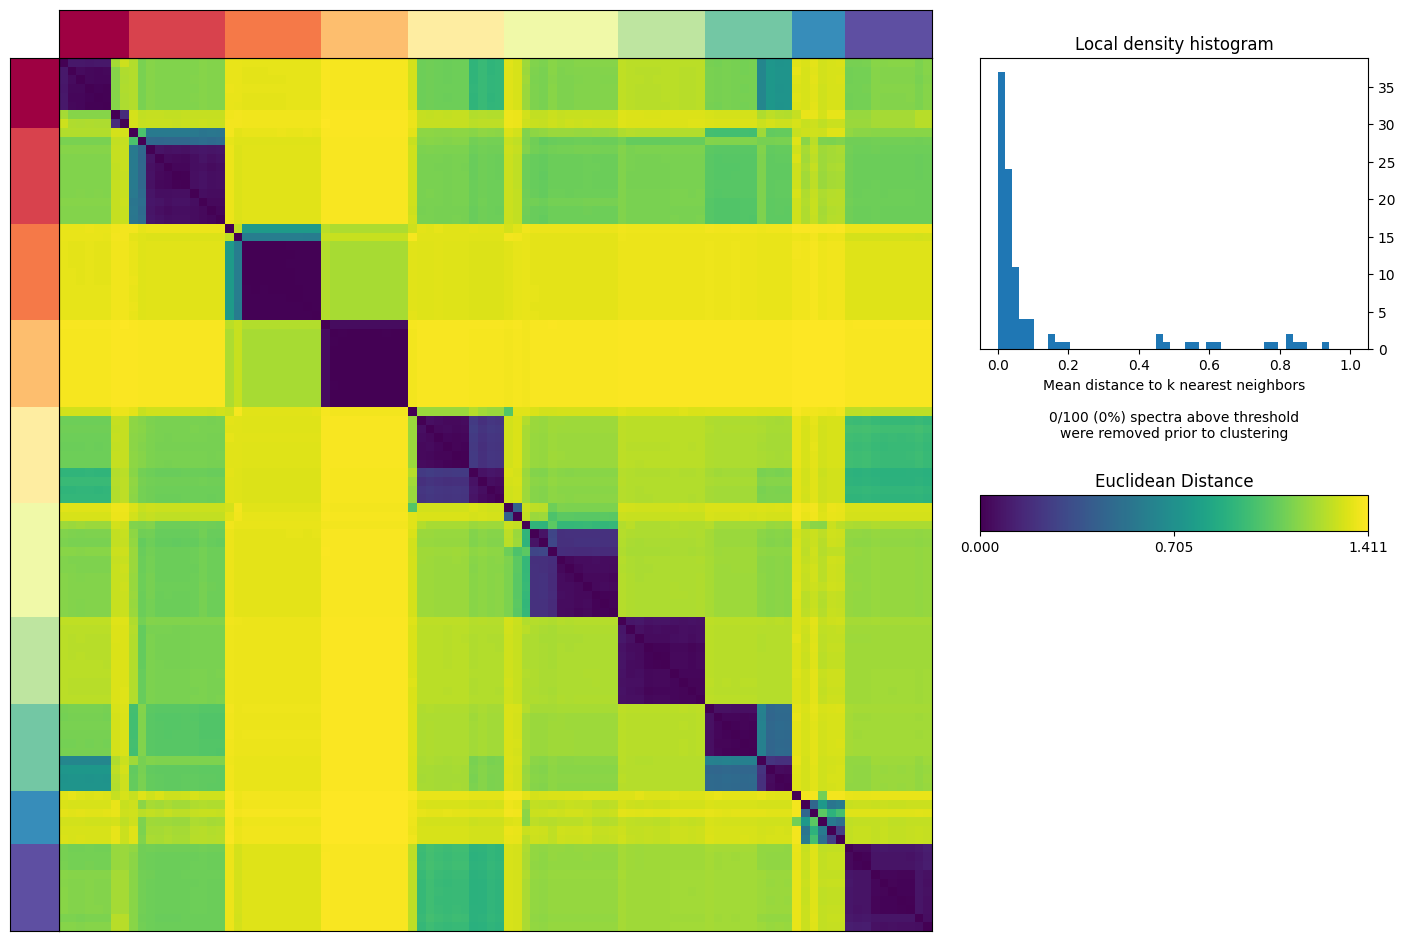

In [11]:
for k in K:
    for thresh in density_thresholds:
        cnmf_obj.consensus(k=k, density_threshold=thresh, show_clustering=True)

## Step 8. Load and Visualize Results

In [12]:
selected_K = 7
selected_thresh = 2.0
thresh_str = str(selected_thresh).replace(".", "_")

usage_norm, gep_scores, gep_tpm, topgenes = cnmf_obj.load_results(
    K=selected_K, density_threshold=selected_thresh
)
usage_norm.columns = [f"Usage_{i}" for i in usage_norm.columns]
usage_norm.head()

,Usage_1,Usage_2,Usage_3,Usage_4,Usage_5,Usage_6,Usage_7
index,,,,,,,
AAACATACAACCAC-1,0.911980,0.006967,0.000000,0.021526,0.059527,0.000000,0.000000
AAACATTGAGCTAC-1,0.400892,0.083243,0.426559,0.023512,0.065387,0.000000,0.000407
AAACATTGATCAGC-1,0.865561,0.056694,0.000000,0.017311,0.053975,0.006459,0.000000
AAACCGTGCTTCCG-1,0.059043,0.749513,0.139007,0.025539,0.012014,0.014146,0.000737
AAACCGTGTATGCG-1,0.168395,0.113452,0.046438,0.631655,0.039245,0.000247,0.000568


In [13]:
topgenes.head(20)

,1,2,3,4,5,6,7
0,RPS12,CST3,CD74,NKG7,RRM2,ITGB5,CHST8
1,RPS27,FTL,HLA-DRA,PRF1,CDC6,C2orf88,AC012499.1
2,RPS25,FTH1,HLA-DQB1,GZMB,TYMS,LRGUK,RGS6
3,EEF1A1,FCER1G,HLA-DQA1,GZMA,MCM10,RP11-874J12.4,RP11-879F14.1
4,RPS15A,TYROBP,HLA-DPB1,GNLY,KIAA0101,AANAT,RP11-88H9.2
5,RPL31,AIF1,HLA-DRB1,FGFBP2,TK1,FSTL4,MAP2
6,RPS27A,COTL1,HLA-DQA2,SPON2,ITGB8,SPDYC,ELOVL7
7,RPS6,LGALS1,HLA-DPA1,CLIC3,CRNDE,GRHL1,TAL1
8,RPLP2,LST1,CD79B,CST7,RP11-27K13.3,PCYT1B,TRAPPC3L
9,RPL23A,S100A4,MS4A1,CTSW,RP11-173D3.1,CAV2,PARD3


## Step 9. UMAP Visualization

In [ ]:
adata = sc.read(counts_fn)

# Get high-variance genes used by cNMF
hvgs_file = os.path.join(inference_dir, "Inference.overdispersed_genes.txt")
hvgs = open(hvgs_file).read().split("\n")
hvgs = [g for g in hvgs if g]  # remove empty strings

# Normalize and process
sc.pp.normalize_per_cell(adata, counts_per_cell_after=1e4)
adata.raw = sc.pp.log1p(adata.copy(), copy=True)
adata = adata[:, hvgs]
sc.pp.scale(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata, n_neighbors=50, n_pcs=15)
sc.tl.umap(adata)

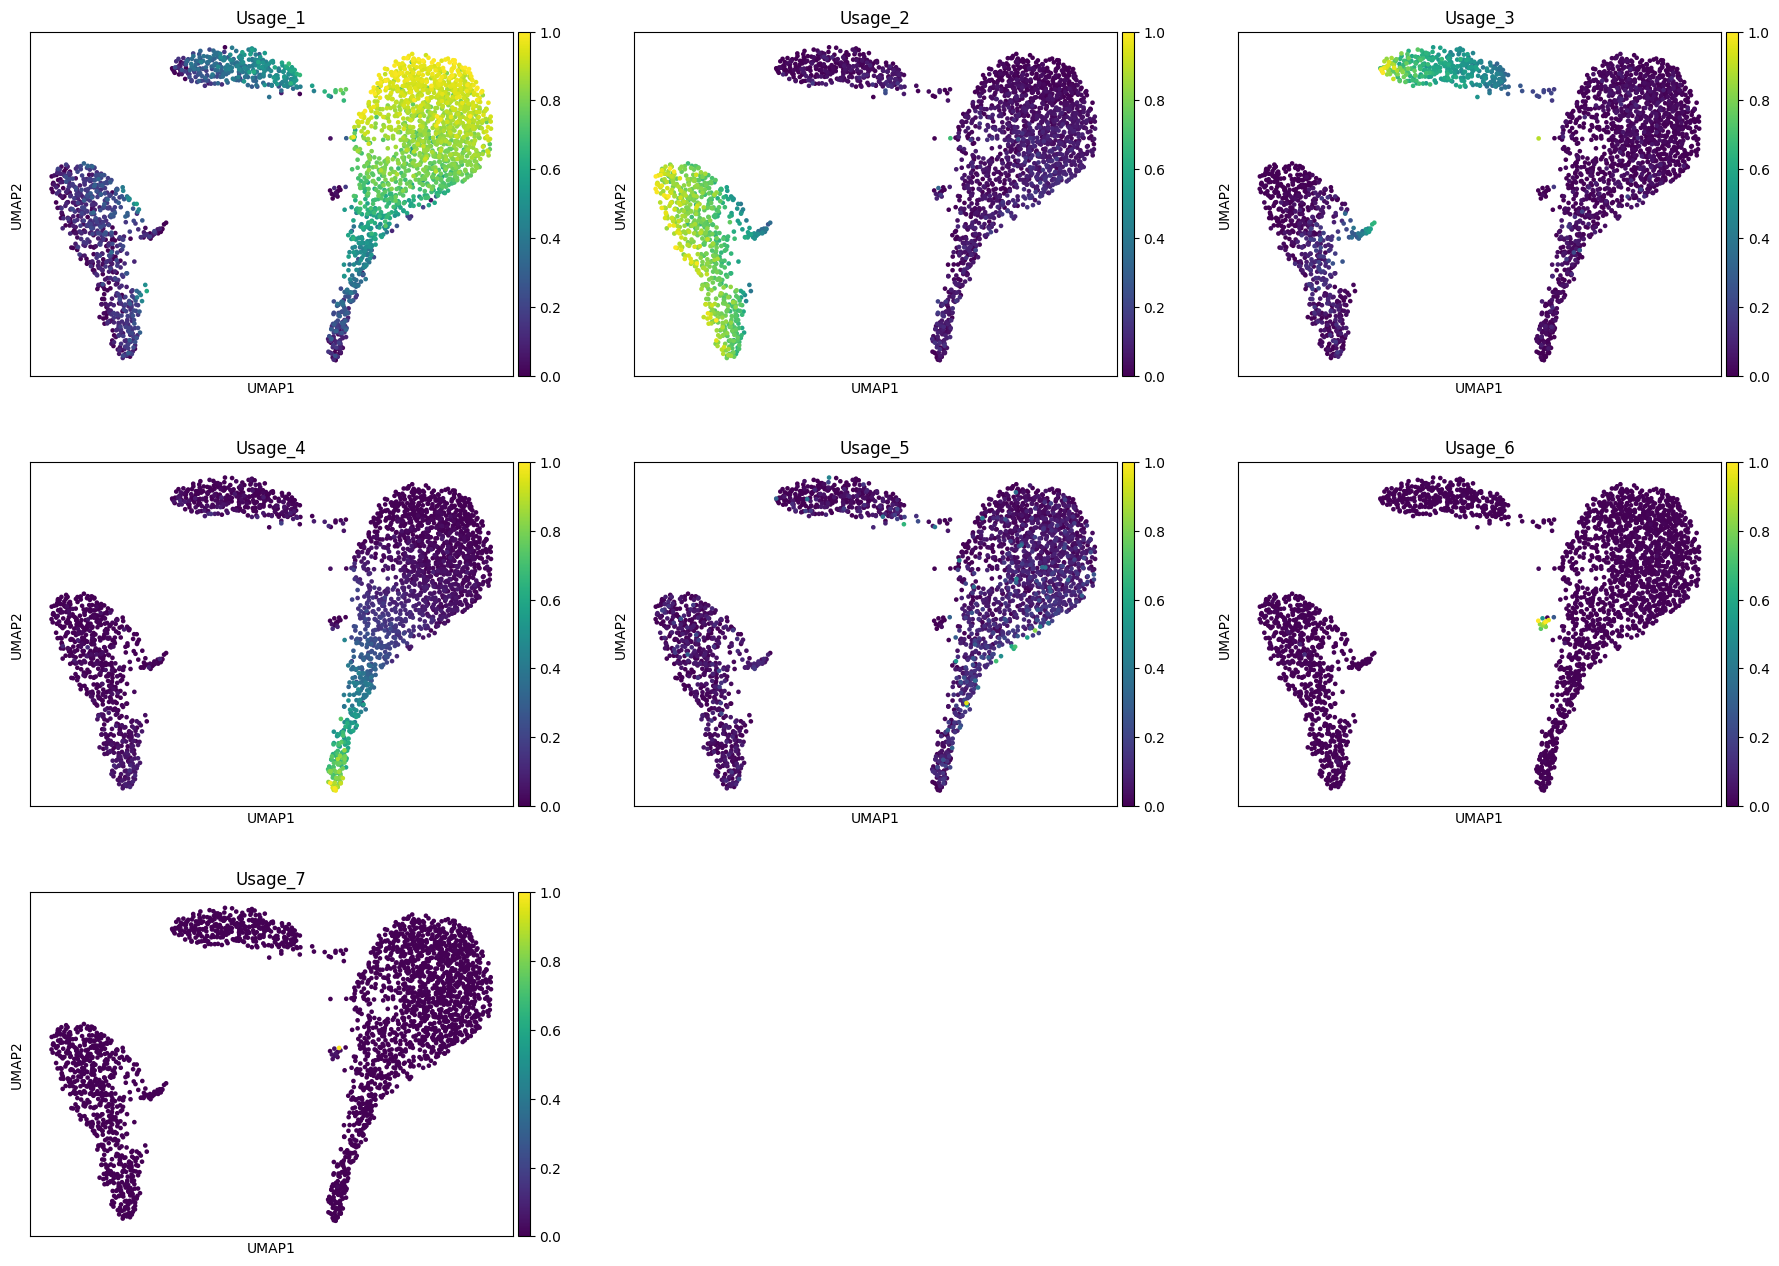

In [15]:
adata.obs = pd.merge(left=adata.obs, right=usage_norm, how="left", left_index=True, right_index=True)
sc.pl.umap(adata, color=usage_norm.columns, use_raw=True, ncols=3, vmin=0, vmax=1)

## Step 10. Save Results to MuData

In [ ]:
# Save all cNMF scores in separate mudata objects
compile_results(run_dir, 'Inference', components=components, sel_threshs=sel_threshs,
     guide_names_key=guide_names_key, guide_targets_key=guide_targets_key, categorical_key=categorical_key, 
     guide_assignment_key=guide_assignment_key, gene_names_key=gene_names_key)

## Step 11. Gene Annotation

In [ ]:
# annotation for all K
os.makedirs(f'{inference_dir}/Annotation', exist_ok=True)
for i in sel_threshs:
    for k in components:
        df = pd.read_csv(f'{inference_dir}/Inference.gene_spectra_score.k_{k}.dt_{str(i).replace(".","_")}.txt',
                         sep='\t', index_col=0)   
        overlap = get_top_indices_fast(df, gene_num=gene_num)
        annotate_genes_to_excel(overlap, species=species, output_file=f'{inference_dir}/Annotation/{k}_{i}.xlsx')